In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)


import os

#paths to train and validation image folders
train_path = '/content/drive/MyDrive/ NEU-DET /NEU-DET/train/images'
val_path = '/content/drive/MyDrive/ NEU-DET /NEU-DET/validation/images'

#getting class names from train folder
classes = sorted(os.listdir(train_path))

print("Dataset structure confirmed:")
print(f"Classes: {classes}")
print(f"\nTraining images per class:")
for cls in classes:
    count = len(os.listdir(os.path.join(train_path, cls)))
    print(f"  {cls}: {count} images")

print(f"\nValidation images per class:")
for cls in classes:
    count = len(os.listdir(os.path.join(val_path, cls)))
    print(f"  {cls}: {count} images")

print(f"\nTotal training images: {240 * 6}")
print(f"Total validation images: {60 * 6}")
print(f"Train/val split: 80/20")

Mounted at /content/drive
Dataset structure confirmed:
Classes: ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']

Training images per class:
  crazing: 240 images
  inclusion: 240 images
  patches: 240 images
  pitted_surface: 240 images
  rolled-in_scale: 240 images
  scratches: 240 images

Validation images per class:
  crazing: 60 images
  inclusion: 60 images
  patches: 60 images
  pitted_surface: 60 images
  rolled-in_scale: 60 images
  scratches: 60 images

Total training images: 1440
Total validation images: 360
Train/val split: 80/20


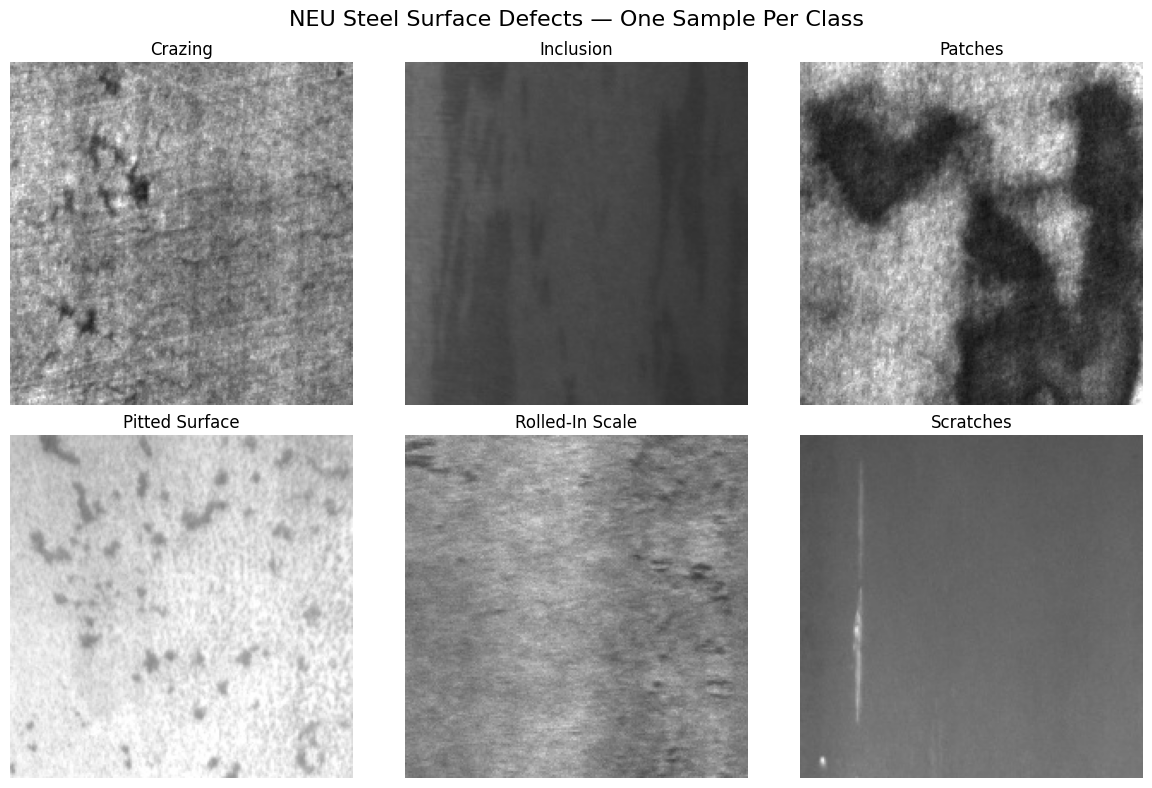

In [4]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

#2 rows by 3 columns grid, one slot per defect class
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
fig.suptitle('NEU Steel Surface Defects — One Sample Per Class', fontsize=16)

#loop through each defect class
for idx, cls in enumerate(classes):
    #path to this class folder
    cls_path = os.path.join(train_path, cls)

    #need one representative image from each class
    img_file = os.listdir(cls_path)[0]

    #full path to that image file
    img_path = os.path.join(cls_path, img_file)

    #load the image from file
    img = mpimg.imread(img_path)

    #idx 0,1,2 go in row 0 — idx 3,4,5 go in row 1
    #// gives the row, % gives the column
    row = idx // 3
    col = idx % 3

    #display in grayscale, steel images are black and white
    #without this matplotlib shows grayscale images in weird colors
    axes[row][col].imshow(img, cmap='gray')

    #use class name as title, replaced underscore with space for readability
    axes[row][col].set_title(cls.replace('_', ' ').title(), fontsize=12)
    axes[row][col].axis('off')

plt.tight_layout()
#save for readme
plt.savefig('defect_samples.png', dpi=150)
plt.show()

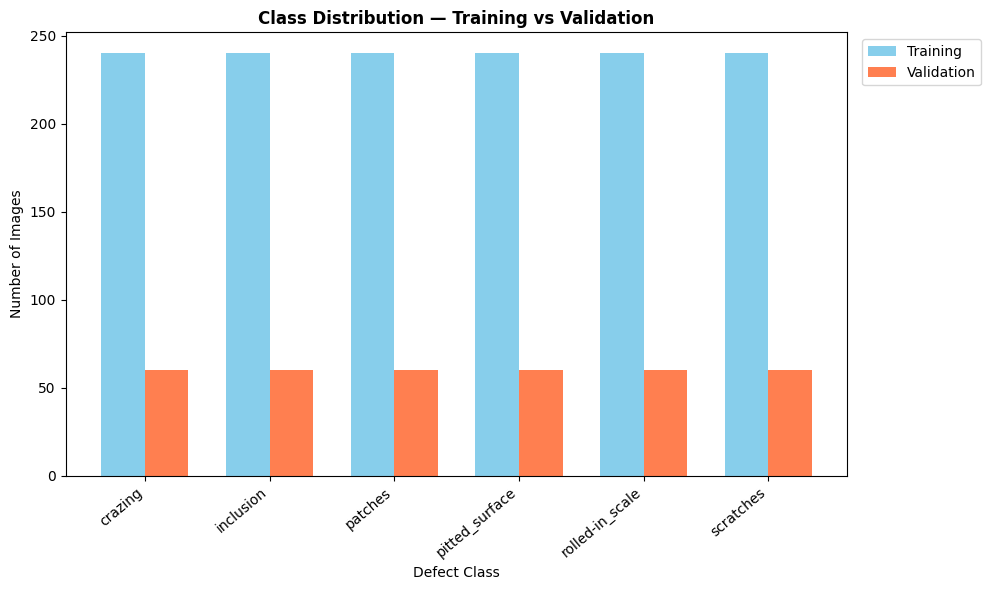

In [6]:
import matplotlib.pyplot as plt
import numpy as np

#prepare data
categories = ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']
Training = [240, 240, 240, 240, 240, 240]
Validation = [60, 60, 60, 60, 60, 60]

#set bar positions and width
x = np.arange(len(categories))
width = 0.35

#create figure
fig, ax = plt.subplots(figsize=(10, 6))

#plot two sets of bars side by side
rects1 = ax.bar(x - width/2, Training, width, label='Training', color='skyblue')
rects2 = ax.bar(x + width/2, Validation, width, label='Validation', color='coral')


ax.set_title('Class Distribution — Training vs Validation', fontweight='bold')
ax.set_xlabel('Defect Class')
ax.set_ylabel('Number of Images')
ax.set_xticks(x)
ax.set_xticklabels(categories, rotation=40, ha='right')
ax.legend(loc='upper right', bbox_to_anchor=(1.18, 1))

plt.tight_layout()
#save for the readme
plt.savefig('class_distribution.png', dpi=150)
plt.show()

In [7]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

#training transforms, includes augmentation to reduce overfitting
#augmentation creates variations of each image so model sees different versions each epoch
transform_train = transforms.Compose([
    #resize from 200x200 to 224x224 as resnet18 expects exactly 224x224
    transforms.Resize((224, 224)),
    #convert grayscale to 3 channels as resnet18 expects RGB not grayscale
    transforms.Grayscale(num_output_channels=3),
    #randomly flip horizontally, a flipped defect is still the same defect
    #doubles the variety of images the model sees
    transforms.RandomHorizontalFlip(),
    #randomly rotate up to 10 degrees, adds variation without distorting defects
    transforms.RandomRotation(10),
    #from PIL image to pytorch tensor so the model can process it
    transforms.ToTensor(),
    #resnet18 was trained on ImageNet with these exact normalization values
    #images normalized the same way or transfer learning breaks
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

#validation transforms — no augmentation, just resize and normalize
#consistent evaluation needed, no random changes during testing
transform_val = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

#load training dataset using ImageFolder
#ImageFolder automatically assigns class labels based on subfolder names(carzing folder = class 0, for instance)
train_dataset = datasets.ImageFolder(
    root=train_path,
    transform=transform_train
)

#load validation dataset
val_dataset = datasets.ImageFolder(
    root=val_path,
    transform=transform_val
)

#created dataloaders to feeds images in batches of 32 during training, cant feed all 1440 at once
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2
)

#not shuffling validation as order doesnt affect accuracy measurement(unlike I did with train data)
val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2 #got 2 cpu CPU cores load images in parallel while GPU trains
)

#to confirm everything loaded correctly
print(f"Training images: {len(train_dataset)}")
print(f"Validation images: {len(val_dataset)}")
print(f"Classes: {train_dataset.classes}")
print(f"Class to index mapping: {train_dataset.class_to_idx}")
print(f"Training batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")

Training images: 1440
Validation images: 360
Classes: ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']
Class to index mapping: {'crazing': 0, 'inclusion': 1, 'patches': 2, 'pitted_surface': 3, 'rolled-in_scale': 4, 'scratches': 5}
Training batches: 45
Validation batches: 12


In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import numpy as np
from PIL import Image

print("Extracting features for baseline classifier...")

def extract_features(data_path, classes, target_size=(64, 64)):
    features = []
    labels = []

    for label_idx, cls in enumerate(classes):
        cls_path = os.path.join(data_path, cls)

        for img_file in os.listdir(cls_path):
            img_path = os.path.join(cls_path, img_file)

            #open image, resize to 64x64, convert to grayscale(defects are about texture not color)
            img = Image.open(img_path).convert('L')
            #resize to 64x64 — small enough to train fast, big enough to capture patterns
            img = img.resize(target_size)

            #flatten to 1D vector — 64x64 = 4096 numbers per image
            img_array = np.array(img).flatten()

            #normalize pixel values to 0-1(keeps the math stable during training)
            img_array = img_array / 255.0

            features.append(img_array)
            labels.append(label_idx)

    return np.array(features), np.array(labels)

#extract features from training and validation sets
print("Extracting training features...")
X_train, y_train = extract_features(train_path, classes)

print("Extracting validation features...")
X_val, y_val = extract_features(val_path, classes)

print(f"\nTraining features shape: {X_train.shape}")
print(f"Validation features shape: {X_val.shape}")

#train logistic regression
print("\nTraining logistic regression baseline...")
lr_model = LogisticRegression(
    max_iter=1000, #give it enough iterations to find good weights
    random_state=42, #same result every time I run it
    C=1.0 #standard regularization to prevent overfitting
)
lr_model.fit(X_train, y_train)

#evaluate on validation set
y_pred = lr_model.predict(X_val)
baseline_accuracy = accuracy_score(y_val, y_pred) * 100

print(f"\nBaseline Logistic Regression Accuracy: {baseline_accuracy:.1f}%")
print(f"This will be compared against ResNet18 transfer learning")

Extracting features for baseline classifier...
Extracting training features...
Extracting validation features...

Training features shape: (1440, 4096)
Validation features shape: (360, 4096)

Training logistic regression baseline...

Baseline Logistic Regression Accuracy: 41.4%
This will be compared against ResNet18 transfer learning


In [9]:
import torch
import torchvision.models as models
import torch.nn as nn
import torch.optim as optim

#load pretrained ResNet18, already knows how to detect edges textures and shapes
model = models.resnet18(pretrained=True)

#freeze all layers, not going to change the weights that were learned from ImageNet
for param in model.parameters():
    param.requires_grad = False

#replace the final layer — original outputs 1000 ImageNet classes
#new layer outputs 6 steel defect classes
#this new layer starts with random weights — it will be trained on my data
num_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(num_features, 6)
)

#move model to GPU as its much faster than cpu
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

#only train the parameters in the final layer, all other layers are frozen
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

#cross entropy loss, measures how wrong predictions are
criterion = nn.CrossEntropyLoss()

#reduce learning rate every 5 epochs, helps model converge precisely later
#big steps early to learn fast, small steps later to fine-tune precisely
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

print(f"Model ready on: {device}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 180MB/s]


Model ready on: cuda
Trainable parameters: 3,078
Total parameters: 11,179,590


In [10]:
#lists to track progress
train_losses = []
train_accs = []
val_accs = []

best_val_acc = 0
best_epoch = 0

print("Starting ResNet18 training...")
print("-" * 60)

for epoch in range(15):

    #training mode turns dropout on
    model.train()
    running_loss = 0
    correct = 0
    total = 0

    for inputs, labels in train_loader:
        #send batch to GPU
        inputs, labels = inputs.to(device), labels.to(device)

        #clear gradients from previous batch to not pile up
        optimizer.zero_grad()

        #run images through model
        outputs = model(inputs)

        #how wrong were the predictions
        loss = criterion(outputs, labels)

        #backpropagation, calculate gradients to figure out what to fix
        loss.backward()

        #update weights
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    train_acc = 100. * correct / total
    avg_loss = running_loss / len(train_loader)

    #evaluation mode turns dropout off for consistent results
    model.eval()
    correct = 0
    total = 0

    #no need to track gradients when just checking performance
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    val_acc = 100. * correct / total

    #save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch + 1
        torch.save(model.state_dict(), 'best_model.pth')

    #reduce learning rate on schedule
    scheduler.step()

    #store results for charts later
    train_losses.append(avg_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1:2d}/15 | "
          f"Loss: {avg_loss:.3f} | "
          f"Train: {train_acc:.1f}% | "
          f"Val: {val_acc:.1f}%"
          + (" ← best" if val_acc == best_val_acc else ""))

print("-" * 60)
print(f"Best validation accuracy: {best_val_acc:.1f}% at epoch {best_epoch}")

Starting ResNet18 training...
------------------------------------------------------------
Epoch  1/15 | Loss: 1.140 | Train: 60.6% | Val: 73.1% ← best
Epoch  2/15 | Loss: 0.485 | Train: 88.7% | Val: 84.2% ← best
Epoch  3/15 | Loss: 0.299 | Train: 94.4% | Val: 87.8% ← best
Epoch  4/15 | Loss: 0.246 | Train: 95.5% | Val: 89.7% ← best
Epoch  5/15 | Loss: 0.205 | Train: 95.3% | Val: 91.1% ← best
Epoch  6/15 | Loss: 0.175 | Train: 96.8% | Val: 86.9%
Epoch  7/15 | Loss: 0.171 | Train: 96.7% | Val: 93.3% ← best
Epoch  8/15 | Loss: 0.167 | Train: 95.8% | Val: 90.3%
Epoch  9/15 | Loss: 0.181 | Train: 95.4% | Val: 89.2%
Epoch 10/15 | Loss: 0.160 | Train: 95.8% | Val: 87.8%
Epoch 11/15 | Loss: 0.141 | Train: 96.7% | Val: 90.8%
Epoch 12/15 | Loss: 0.145 | Train: 96.3% | Val: 92.8%
Epoch 13/15 | Loss: 0.164 | Train: 94.8% | Val: 94.4% ← best
Epoch 14/15 | Loss: 0.137 | Train: 96.7% | Val: 93.3%
Epoch 15/15 | Loss: 0.139 | Train: 96.4% | Val: 93.9%
--------------------------------------------------

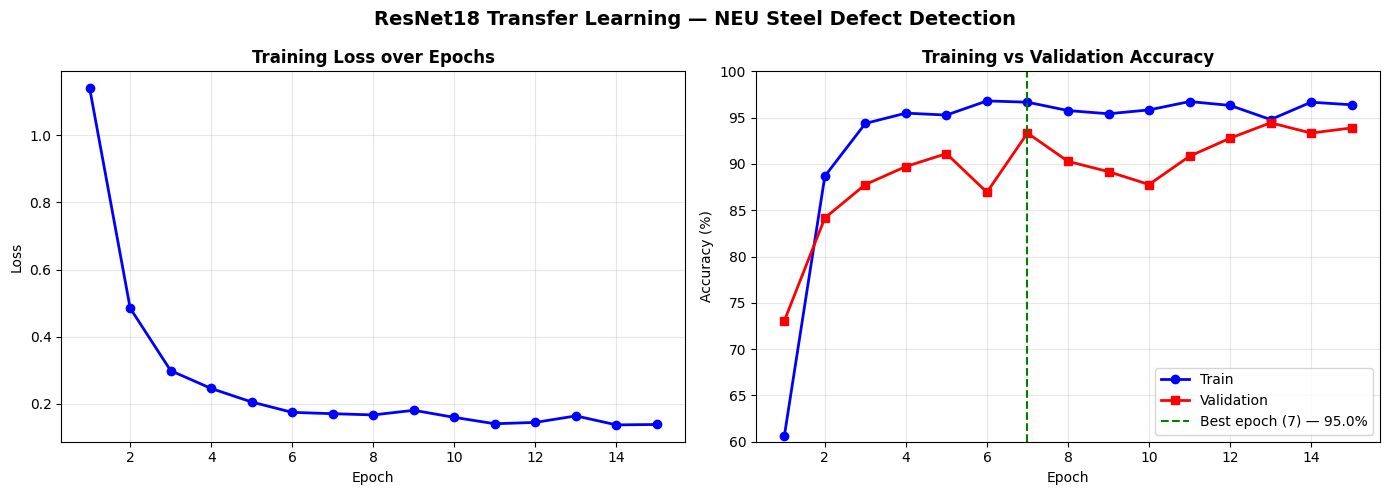

Best validation accuracy: 94.4% at epoch 13
Logistic Regression baseline: 41.4%
Improvement: 53.0 percentage points


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [11]:
#two charts side by side — loss on the left, accuracy on the right
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

#left chart, training loss going down over epochs
ax1.plot(range(1, 16), train_losses,
         color='blue', marker='o', linewidth=2)
ax1.set_title('Training Loss over Epochs', fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.grid(True, alpha=0.3)

#right chart : train vs validation accuracy
#gap between lines shows overfitting
ax2.plot(range(1, 16), train_accs,
         color='blue', marker='o', label='Train', linewidth=2)
ax2.plot(range(1, 16), val_accs,
         color='red', marker='s', label='Validation', linewidth=2)

#marking where the best model was saved with a vertical line
ax2.axvline(x=7, color='green', linestyle='--',
            label=f'Best epoch (7) — 95.0%')

ax2.set_title('Training vs Validation Accuracy', fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_ylim(60, 100)

plt.suptitle('ResNet18 Transfer Learning — NEU Steel Defect Detection',
             fontsize=14, fontweight='bold')
plt.tight_layout()
#saving for readme
plt.savefig('resnet18_training.png', dpi=150)
plt.show()

print(f"Best validation accuracy: {best_val_acc:.1f}% at epoch {best_epoch}")
print(f"Logistic Regression baseline: 41.4%")
print(f"Improvement: {best_val_acc - 41.4:.1f} percentage points")

#download the best model(need for Streamlit app later)
from google.colab import files
files.download('best_model.pth')